# So sánh AOD AERONET vs VIIRS NOAA-20 (Petrenko/Ichoku collocation)

**Tiêu chí collocation (Petrenko-Ichoku, áp dụng cho VIIRS polar-orbit):**

| Tham số | Giá trị | Lý do |
|---|---|---|
| Spatial radius | **±25 km** quanh trạm AERONET | File đã pre-aggregate trong `threshold_km = 25 km` |
| Temporal window | **±30 phút** quanh thời điểm vệ tinh | VIIRS NOAA-20 polar-orbit, 1-2 lượt/ngày |
| Bước sóng | **550 nm** | VIIRS AOT @ 550 nm; AERONET interp 550 nm |
| Min satellite pixels | **≥ 2** | `n_pixels` |
| Min AERONET obs | **≥ 2** | Tránh đo lỗi |
| CoV satellite | **< 0.5** | `aod_std / aod_mean` |

**Nguồn VIIRS:** `/home/slow_data/Air_Quality/VIIRS/output/L2_NOAA20/{station}.csv`
— file đã trích sẵn trong bán kính 25 km quanh trạm, kèm `aod_mean`, `aod_std`, `n_pixels`, `aod_median`.

In [53]:
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import RANSACRegressor, LinearRegression

VIIRS_ROOT = Path('/home/slow_data/Air_Quality/VIIRS/output/L2_NOAA20')
AER_ROOT   = Path('/home/slow_data/Air_Quality/AERONET/process/aod_550/10')

STATIONS = ['NGHIA_DO', 'Bac_Lieu']

DT_MIN  = 30    # ±30 phút (polar-orbit)
MIN_SAT = 2     # n_pixels
MIN_AER = 2
MAX_COV = 0.5

## 1. AERONET — lọc AOD 550 nm

In [54]:
def load_aeronet(station):
    df = pd.read_csv(AER_ROOT / f'{station}.csv', low_memory=False)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[['datetime', 'aod_550', 'ae']].rename(columns={'aod_550': 'aod550'})
    df = df[df['aod550'].between(0, 5)]
    return df.sort_values('datetime').reset_index(drop=True)

aer = {s: load_aeronet(s) for s in STATIONS}
for s, df in aer.items():
    print(f'{s}: {len(df):,} obs, {df.datetime.min()} -> {df.datetime.max()}')
aer['NGHIA_DO'].head(3)

NGHIA_DO: 13,279 obs, 2022-02-23 13:56:22 -> 2026-05-01 06:36:44
Bac_Lieu: 15,695 obs, 2022-04-21 06:38:46 -> 2025-08-22 10:16:10


,datetime,aod550,ae
0,2022-02-23 13:56:22,0.589588,1.316554
1,2022-02-23 14:01:22,0.601053,1.307935
2,2022-02-23 14:06:22,0.602714,1.292318


## 2. VIIRS — đọc thẳng file đã pre-aggregate

Cột dùng:
- `aod_mean`, `aod_std`, `n_pixels` → trung bình toàn cửa sổ trong 25 km
- Lọc Petrenko: `n_pixels ≥ 2`, `CoV = aod_std / aod_mean < 0.5`

In [55]:
VIIRS_COLS = ['datetime', 'aod_mean', 'aod_median', 'aod_std',
              'n_pixels', 'mean_dist_km', 'source_sds']

def load_viirs(station):
    df = pd.read_csv(VIIRS_ROOT / f'{station}.csv', usecols=VIIRS_COLS, low_memory=False)
    df['ts'] = pd.to_datetime(df['datetime'])
    df = df.dropna(subset=['aod_mean'])
    df = df[df['aod_mean'].between(0, 5)]
    return df.sort_values('ts').reset_index(drop=True)

viirs = {s: load_viirs(s) for s in STATIONS}
for s, df in viirs.items():
    print(f'{s}: {len(df):,} scenes, {df.ts.min()} -> {df.ts.max()}')
viirs['NGHIA_DO'].head(3)

NGHIA_DO: 342 scenes, 2022-01-02 12:36:00 -> 2026-05-04 12:36:00
Bac_Lieu: 485 scenes, 2022-01-01 12:54:00 -> 2026-05-19 12:48:00


,datetime,aod_mean,aod_median,aod_std,n_pixels,mean_dist_km,source_sds,ts
0,2022-01-02 12:36:00,0.545231,0.536717,0.062530,8,21.313492,Best_Estimate,2022-01-02 12:36:00
1,2022-01-18 12:36:00,0.330124,0.312336,0.068871,21,14.099180,Best_Estimate,2022-01-18 12:36:00
2,2022-01-19 12:18:00,0.516499,0.514663,0.074219,35,16.384204,Best_Estimate,2022-01-19 12:18:00


## 3. Collocation

Với mỗi overpass VIIRS hợp lệ (N≥2, CoV<0.5):
- Tìm các đo AERONET trong **±30 phút** quanh `ts`.
- Cần ≥ 2 đo AERONET → lấy mean.

In [56]:
def collocate(station, df_aer, df_v):
    df_h = df_v.copy()
    df_h['cov'] = df_h['aod_std'] / df_h['aod_mean'].replace(0, np.nan)
    df_h = df_h[(df_h['n_pixels'] >= MIN_SAT) & (df_h['cov'] < MAX_COV)]

    a_times = df_aer['datetime'].values.astype('datetime64[ns]')
    a_vals  = df_aer['aod550'].values
    dt_ns   = np.timedelta64(DT_MIN, 'm')

    rows = []
    for _, r in df_h.iterrows():
        ts = np.datetime64(r['ts'])
        mask = (a_times >= ts - dt_ns) & (a_times <= ts + dt_ns)
        if mask.sum() < MIN_AER:
            continue
        sub = a_vals[mask]
        rows.append({
            'station':       station,
            'ts':            r['ts'],
            'aer_mean':      float(sub.mean()),
            'aer_std':       float(sub.std(ddof=0)),
            'aer_n':         int(mask.sum()),
            'sat_mean':      float(r['aod_mean']),
            'sat_median':    float(r['aod_median']),
            'sat_std':       float(r['aod_std']),
            'sat_cov':       float(r['cov']),
            'sat_n':         int(r['n_pixels']),
            'sat_dist_km':   float(r['mean_dist_km']),
            'sat_source':    r.get('source_sds', ''),
        })
    return pd.DataFrame(rows)

In [57]:
pairs = pd.concat(
    [collocate(s, aer[s], viirs[s]) for s in STATIONS],
    ignore_index=True,
)
print(f'Total pairs: {len(pairs):,}')
print(pairs.groupby('station').size())
pairs.head()

Total pairs: 314
station
Bac_Lieu    149
NGHIA_DO    165
dtype: int64


,station,ts,aer_mean,aer_std,aer_n,sat_mean,sat_median,sat_std,sat_cov,sat_n,sat_dist_km,sat_source
0,NGHIA_DO,2022-02-24 12:42:00,0.521996,0.021997,8,0.622660,0.614934,0.106438,0.170940,26,16.042671,Best_Estimate
1,NGHIA_DO,2022-02-25 12:24:00,1.077071,0.099482,5,0.882564,0.837562,0.129418,0.146639,18,19.187350,Best_Estimate
2,NGHIA_DO,2022-03-03 12:12:00,1.148048,0.064454,4,1.006885,1.006885,0.029709,0.029506,2,22.658900,Best_Estimate
3,NGHIA_DO,2022-03-08 12:18:00,0.340470,0.021208,8,0.352083,0.329103,0.063649,0.180778,33,17.645513,Best_Estimate
4,NGHIA_DO,2022-03-08 14:00:00,0.376085,0.020311,9,0.500288,0.492342,0.088272,0.176443,21,18.708708,Best_Estimate


## 4. Metrics

- **R**: Pearson correlation
- **RMSE**, **MAE**, **MBE**
- **EE envelope**: tỉ lệ điểm trong `±(0.05 + 0.15·AOD_AERONET)`
- **OLS**: simple linear regression (`y = slope·x + intercept`)
- **RANSAC**: robust regression (loại outlier) → `slope_r`, `intercept_r`, `N_in` inliers

In [58]:
def fit_ransac(x, y, seed=0):
    if len(x) < 3:
        return np.nan, np.nan, 0
    try:
        ransac = RANSACRegressor(
            estimator=LinearRegression(),
            min_samples=max(2, int(0.2 * len(x))),
            residual_threshold=None,  # MAD-based
            random_state=seed,
        ).fit(x.reshape(-1, 1), y)
        slope = float(ransac.estimator_.coef_[0])
        intercept = float(ransac.estimator_.intercept_)
        n_in = int(ransac.inlier_mask_.sum())
        return slope, intercept, n_in
    except ValueError:
        return np.nan, np.nan, 0

def evaluate(df, sat_col='sat_mean'):
    sub = df.dropna(subset=['aer_mean', sat_col])
    x = sub['aer_mean'].values
    y = sub[sat_col].values
    n = len(sub)
    if n < 2:
        return {'N': n, 'R': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
                'MBE': np.nan, 'within_EE': np.nan,
                'slope': np.nan, 'intercept': np.nan,
                'slope_r': np.nan, 'intercept_r': np.nan, 'N_in': 0}
    r, _ = stats.pearsonr(x, y)
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    mae  = float(np.mean(np.abs(y - x)))
    mbe  = float(np.mean(y - x))
    ee   = 0.05 + 0.15 * x
    within_ee = float(np.mean((y - x >= -ee) & (y - x <= ee)))
    slope, intercept = np.polyfit(x, y, 1)
    slope_r, intercept_r, n_in = fit_ransac(x, y)
    return {'N': n, 'R': r, 'RMSE': rmse, 'MAE': mae, 'MBE': mbe,
            'within_EE': within_ee,
            'slope': float(slope), 'intercept': float(intercept),
            'slope_r': slope_r, 'intercept_r': intercept_r, 'N_in': n_in}

summary = {'ALL': evaluate(pairs)}
for s, grp in pairs.groupby('station'):
    summary[s] = evaluate(grp)
pd.DataFrame(summary).T.round(3)

,N,R,RMSE,MAE,MBE,within_EE,slope,intercept,slope_r,intercept_r,N_in
ALL,314.0,0.902,0.231,0.138,0.040,0.570,0.999,0.040,0.884,0.075,252.0
Bac_Lieu,149.0,0.882,0.138,0.108,0.085,0.463,0.763,0.138,0.842,0.108,117.0
NGHIA_DO,165.0,0.898,0.291,0.164,-0.001,0.667,1.108,-0.076,0.991,-0.010,139.0


## 5. Scatter + EE envelope

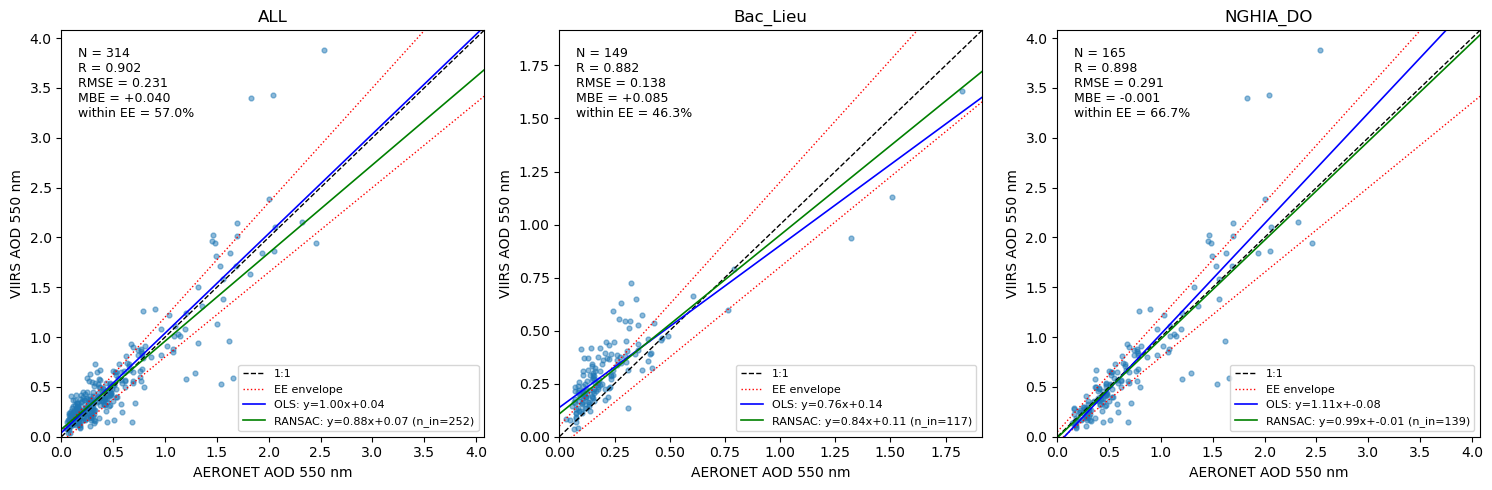

In [59]:
def plot_scatter(ax, df, label, sat_col='sat_mean'):
    sub = df.dropna(subset=['aer_mean', sat_col])
    if len(sub) == 0:
        ax.set_title(f'{label} - empty'); return
    x = sub['aer_mean'].values; y = sub[sat_col].values
    m = evaluate(sub, sat_col)
    ax.scatter(x, y, s=12, alpha=0.5)
    lim = max(x.max(), y.max()) * 1.05
    grid = np.linspace(0, lim, 100)
    ax.plot(grid, grid, 'k--', lw=1, label='1:1')
    ax.plot(grid, grid + (0.05 + 0.15 * grid), 'r:', lw=1, label='EE envelope')
    ax.plot(grid, grid - (0.05 + 0.15 * grid), 'r:', lw=1)
    if np.isfinite(m['slope']):
        ax.plot(grid, m['slope'] * grid + m['intercept'], 'b-', lw=1.2,
                label=f"OLS: y={m['slope']:.2f}x+{m['intercept']:.2f}")
    if np.isfinite(m['slope_r']):
        ax.plot(grid, m['slope_r'] * grid + m['intercept_r'], 'g-', lw=1.2,
                label=f"RANSAC: y={m['slope_r']:.2f}x+{m['intercept_r']:.2f} (n_in={m['N_in']})")
    txt = (f"N = {m['N']}\nR = {m['R']:.3f}\nRMSE = {m['RMSE']:.3f}\n"
           f"MBE = {m['MBE']:+.3f}\nwithin EE = {m['within_EE']*100:.1f}%")
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('AERONET AOD 550 nm'); ax.set_ylabel('VIIRS AOD 550 nm')
    ax.set_title(label); ax.legend(loc='lower right', fontsize=8)

groups = [('ALL', pairs)] + [(s, g) for s, g in pairs.groupby('station')]
fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 5), squeeze=False)
for j, (g_label, df) in enumerate(groups):
    plot_scatter(axes[0, j], df, g_label)
fig.tight_layout(); plt.show()

## 6. Bias theo AOD bin và theo giờ UTC

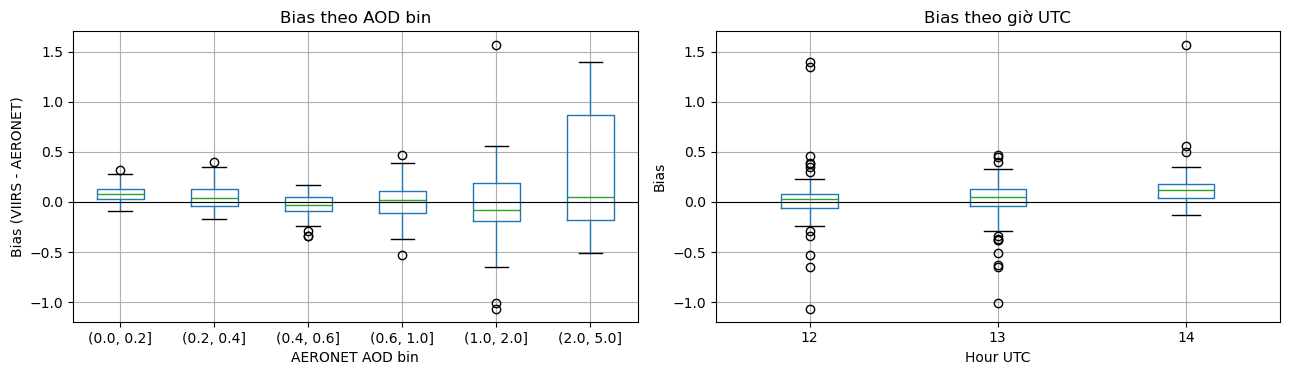

In [60]:
if len(pairs):
    pairs['bias']     = pairs.sat_mean - pairs.aer_mean
    pairs['hour_utc'] = pd.to_datetime(pairs.ts).dt.hour
    pairs['aod_bin']  = pd.cut(pairs.aer_mean,
                               bins=[0, 0.2, 0.4, 0.6, 1.0, 2.0, 5.0])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    pairs.boxplot(column='bias', by='aod_bin', ax=axes[0])
    axes[0].axhline(0, color='k', lw=0.8)
    axes[0].set_title('Bias theo AOD bin')
    axes[0].set_xlabel('AERONET AOD bin'); axes[0].set_ylabel('Bias (VIIRS - AERONET)')
    pairs.boxplot(column='bias', by='hour_utc', ax=axes[1])
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_title('Bias theo giờ UTC')
    axes[1].set_xlabel('Hour UTC'); axes[1].set_ylabel('Bias')
    plt.suptitle(''); fig.tight_layout(); plt.show()

## 7. Density scatter theo giờ UTC

Mỗi panel là một giờ UTC. Mật độ điểm tô màu bằng Gaussian KDE — đỉnh đỏ/vàng = vùng tập trung, đuôi xanh = outlier. Hiển thị hour có ≥ `MIN_N_HOUR` cặp.

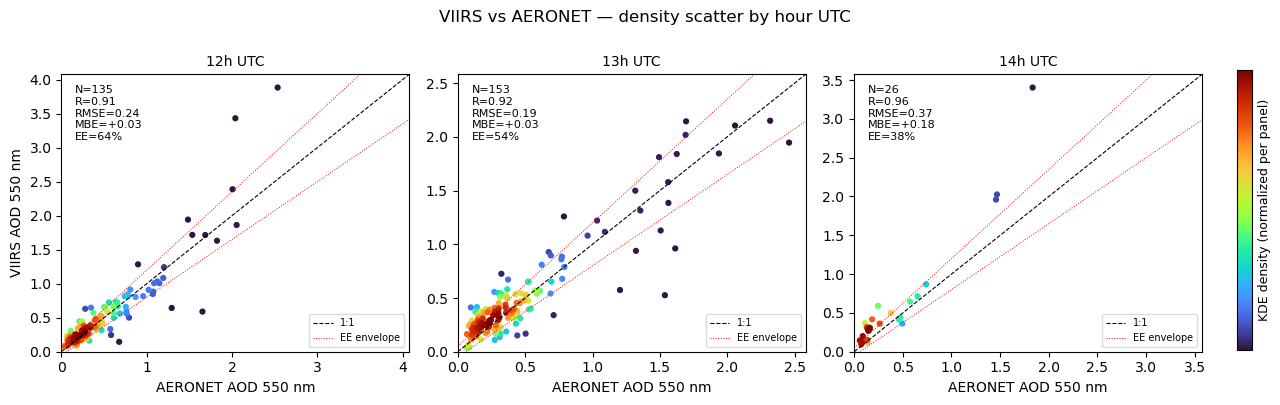

In [61]:
MIN_N_HOUR = 5
NCOLS_HOUR = 3

def _density_panel(ax, x, y, label):
    n = len(x)
    sc = None
    if n == 0:
        ax.set_title(f'{label} - empty'); ax.set_axis_off(); return sc
    if n >= 5:
        try:
            xy = np.vstack([x, y])
            z = stats.gaussian_kde(xy)(xy)
            order = z.argsort()
            x, y, z = x[order], y[order], z[order]
            sc = ax.scatter(x, y, c=z, s=12, cmap='turbo')
        except Exception:
            ax.scatter(x, y, s=12, alpha=0.5)
    else:
        ax.scatter(x, y, s=12, alpha=0.5)
    lim = max(float(x.max()), float(y.max()), 0.1) * 1.05
    grid = np.linspace(0, lim, 100)
    l_11, = ax.plot(grid, grid, 'k--', lw=0.8, label='1:1')
    l_ee, = ax.plot(grid, grid + (0.05 + 0.15 * grid), 'r:', lw=0.7, label='EE envelope')
    ax.plot(grid, grid - (0.05 + 0.15 * grid), 'r:', lw=0.7)
    if n >= 2:
        r, _ = stats.pearsonr(x, y)
        rmse = float(np.sqrt(np.mean((y - x) ** 2)))
        mbe  = float(np.mean(y - x))
        ee   = 0.05 + 0.15 * x
        within = float(np.mean((y - x >= -ee) & (y - x <= ee)))
        txt = (f"N={n}\nR={r:.2f}\nRMSE={rmse:.2f}\n"
               f"MBE={mbe:+.2f}\nEE={within*100:.0f}%")
        ax.text(0.04, 0.96, txt, transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(label, fontsize=10)
    ax.legend(handles=[l_11, l_ee], loc='lower right', fontsize=7, framealpha=0.7)
    return sc

def density_scatter_by_hour(df, sat_col='sat_mean', sensor_label='VIIRS'):
    sub = df.dropna(subset=['aer_mean', sat_col]).copy()
    sub['hour_utc'] = pd.to_datetime(sub.ts).dt.hour
    counts = sub.groupby('hour_utc').size()
    hours = sorted(counts[counts >= MIN_N_HOUR].index.tolist())
    if not hours:
        print(f'{sensor_label}: no hour has >= {MIN_N_HOUR} pairs'); return
    nrows = int(np.ceil(len(hours) / NCOLS_HOUR))
    fig, axes = plt.subplots(nrows, NCOLS_HOUR,
                             figsize=(4 * NCOLS_HOUR + 1, 4 * nrows), squeeze=False)
    last_sc = None
    for i, h in enumerate(hours):
        ax = axes[i // NCOLS_HOUR, i % NCOLS_HOUR]
        g = sub[sub.hour_utc == h]
        sc = _density_panel(ax, g['aer_mean'].values, g[sat_col].values, f'{h:02d}h UTC')
        if sc is not None:
            last_sc = sc
        if i // NCOLS_HOUR == nrows - 1:
            ax.set_xlabel('AERONET AOD 550 nm')
        if i % NCOLS_HOUR == 0:
            ax.set_ylabel(f'{sensor_label} AOD 550 nm')
    for j in range(len(hours), nrows * NCOLS_HOUR):
        axes[j // NCOLS_HOUR, j % NCOLS_HOUR].set_axis_off()
    fig.suptitle(f'{sensor_label} vs AERONET — density scatter by hour UTC',
                 y=1.0, fontsize=12)
    fig.tight_layout(rect=[0, 0, 0.94, 1.0])
    if last_sc is not None:
        cax = fig.add_axes([0.955, 0.15, 0.012, 0.7])
        cbar = fig.colorbar(last_sc, cax=cax)
        cbar.set_label('KDE density (normalized per panel)', fontsize=9)
        cbar.set_ticks([])
    plt.show()

density_scatter_by_hour(pairs)

In [62]:
out = Path('/home/slow_data/Air_Quality/VIIRS/aeronet_viirs_pairs.csv')
pairs.to_csv(out, index=False)
print('Saved:', out, '-', len(pairs), 'rows')

Saved: /home/slow_data/Air_Quality/VIIRS/aeronet_viirs_pairs.csv - 314 rows
